<a href="https://colab.research.google.com/github/rohini-th/Ai/blob/main/Final_review.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import nltk
from  nltk.tokenize import word_tokenize


from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input,LSTM,Embedding,Dropout
from tensorflow.keras.callbacks import EarlyStopping


# **Data Gathering**

In [1]:
import pandas as pd

df = pd.read_csv(
    "/content/Reviews.csv",
    usecols=["Text"],
    nrows=10000,
    engine="python",
    on_bad_lines="skip"
)


# **Preprocessing**

In [2]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z ]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df["Text"] = df["Text"].apply(clean_text)
df = df[df["Text"] != ""]

# **Tokenization**

In [3]:
tokenizer = Tokenizer(num_words=1000, oov_token="<OOV>")
tokenizer.fit_on_texts(df["Text"])

total_words = 5000

**Generate the Input sequences and then apply pad sequences**

In [4]:
input_sequences = []

for sentence in df["Text"]:
    token_list = tokenizer.texts_to_sequences([sentence])[0]

    for i in range(1, len(token_list)):
        input_sequences.append(token_list[:i + 1])

In [5]:

MAX_LEN = 30

input_sequences = pad_sequences(
    input_sequences,
    maxlen=MAX_LEN,
    padding="pre",
    truncating="pre"
)

In [6]:
X = input_sequences[:, :-1]
y = input_sequences[:, -1].astype("int32")

# **Model Building**

In [7]:

model = Sequential([
    Embedding(5000, 100),
    LSTM(128),
    Dropout(0.2),
    Dense(5000, activation="softmax")
])

In [8]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# **Model Traning**

In [9]:
history = model.fit(
    X,
    y,
    epochs=15,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/15
21760/21760 ━━━━━━━━━━━━━━━━━━━━ 177s 8ms/step - accuracy: 0.1962 - loss: 4.4155 - val_accuracy: 0.2127 - val_loss: 4.1119
Epoch 2/15
21760/21760 ━━━━━━━━━━━━━━━━━━━━ 168s 8ms/step - accuracy: 0.2209 - loss: 4.0506 - val_accuracy: 0.2243 - val_loss: 3.9401
Epoch 3/15
21760/21760 ━━━━━━━━━━━━━━━━━━━━ 207s 8ms/step - accuracy: 0.2287 - loss: 3.9371 - val_accuracy: 0.2338 - val_loss: 3.8583
Epoch 4/15
21760/21760 ━━━━━━━━━━━━━━━━━━━━ 210s 8ms/step - accuracy: 0.2349 - loss: 3.8687 - val_accuracy: 0.2372 - val_loss: 3.8115
Epoch 5/15
21760/21760 ━━━━━━━━━━━━━━━━━━━━ 193s 8ms/step - accuracy: 0.2387 - loss: 3.8215 - val_accuracy: 0.2414 - val_loss: 3.7759
Epoch 6/15
21760/21760 ━━━━━━━━━━━━━━━━━━━━ 167s 8ms/step - accuracy: 0.2411 - loss: 3.7909 - val_accuracy: 0.2412 - val_loss: 3.7559
Epoch 7/15
21760/21760 ━━━━━━━━━━━━━━━━━━━━ 174s 8ms/step - accuracy: 0.2432 - loss: 3.7647 - val_accuracy: 0.2467 - val_loss: 3.7379
Epoch 8/15
21760/21760 ━━━━━━━━━━━━━━━━━━━━ 167s 8ms/step - ac

# Text Generation method

In [10]:

def generate_text(seed_text, next_words, temperature=0.8):

    for _ in range(next_words):

        # Convert text to sequence
        token_list = tokenizer.texts_to_sequences([seed_text])[0]

        # Pad sequence
        token_list = pad_sequences(
            [token_list],
            maxlen=MAX_LEN-1,
            padding='pre',
            truncating='pre'
        )

        # Predict probabilities
        preds = model.predict(token_list, verbose=0)[0]

        # Temperature Sampling
        preds = np.asarray(preds).astype("float64")
        preds = np.log(preds + 1e-8) / temperature
        exp_preds = np.exp(preds)
        preds = exp_preds / np.sum(exp_preds)

        # Randomly sample next word
        predicted = np.random.choice(len(preds), p=preds)

        # Convert index to word
        output_word = tokenizer.index_word.get(predicted, "")

        # Skip invalid predictions
        if output_word == "" or output_word == "<OOV>":
            continue

        # Avoid repeating the previous word
        if seed_text.split()[-1] == output_word:
            continue

        seed_text += " " + output_word

    return seed_text

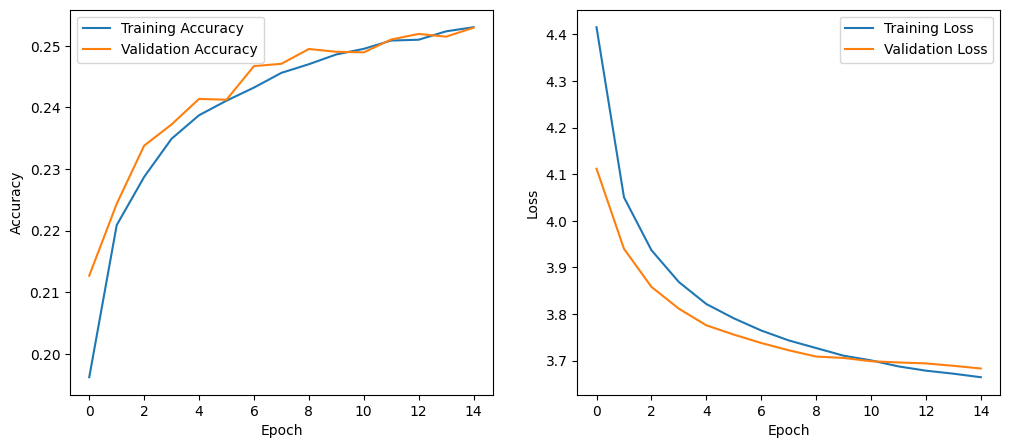

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [12]:

model.save("text_generation_lstm.keras")



In [20]:
print(generate_text("this food", 30))



print(generate_text("\n i love", 30))
print(generate_text("\n the taste", 30))
print(generate_text("\n Great food", 30))



this food is the low calorie cracker and some of the two mixes the taste is a bit too sweet and the cheese is

 i love a lot of organic brands and it was great in a great way to order it but it s not my favorite

 the taste is very good br a little the aroma and taste the same thing it worked great because i use it from my

 Great food from the vet s lb can of this product ingredients i personally like to be
